# Introducción a la Convolución

La convolución es una operación matemática fundamental en el procesamiento de señales, imágenes y también en redes neuronales convolucionales. Permite combinar dos funciones para producir una tercera que representa cómo la forma de una es modificada por la otra.

## Definición Matemática

La convolución de dos funciones $f$ y $g$ se denota como $f * g$ y se define matemáticamente como:

### Convolución Continua
$(f * g)(t) = \int_{-\infty}^{\infty} f(\tau) g(t-\tau) d\tau$

### Convolución Discreta
Para señales discretas, la convolución se define como:

$(f * g)[n] = \sum_{m=-\infty}^{\infty} f[m] g[n-m]$

En el procesamiento de imágenes, utilizamos convolución bidimensional:

$(f * g)[i, j] = \sum_{m} \sum_{n} f[m, n] g[i-m, j-n]$

## Convolución con NumPy

Veamos cómo implementar la convolución usando NumPy:

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Configuración para mostrar gráficos más grandes
plt.figure(figsize=(12, 6))

<Figure size 1200x600 with 0 Axes>

### Convolución 1D

Vamos a implementar la convolución 1D con un ejemplo sencillo:

Señal original: [1 2 3 4 5]
Kernel: [0.5 1.  0.5]
Convolución (full): [0.5 2.  4.  6.  8.  7.  2.5]
Convolución (same): [2. 4. 6. 8. 7.]
Convolución (valid): [4. 6. 8.]


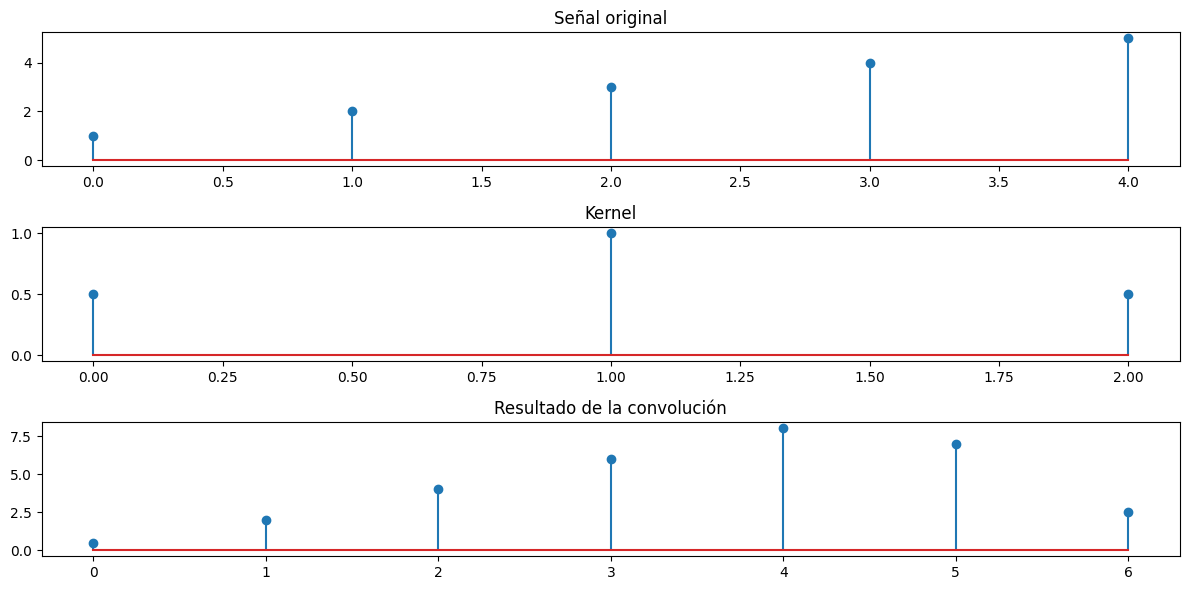

In [2]:
# Definimos dos señales discretas
signal = np.array([1, 2, 3, 4, 5])
kernel = np.array([0.5, 1, 0.5])

# Usamos np.convolve para calcular la convolución
# 'full': devuelve la convolución completa
# 'same': devuelve solo la parte central de la convolución, del mismo tamaño que signal
# 'valid': devuelve solo las partes donde las señales se superponen completamente
convolution_full = np.convolve(signal, kernel, mode='full')
convolution_same = np.convolve(signal, kernel, mode='same')
convolution_valid = np.convolve(signal, kernel, mode='valid')

print("Señal original:", signal)
print("Kernel:", kernel)
print("Convolución (full):", convolution_full)
print("Convolución (same):", convolution_same)
print("Convolución (valid):", convolution_valid)

# Visualización
plt.subplot(3, 1, 1)
plt.stem(signal)
plt.title("Señal original")

plt.subplot(3, 1, 2)
plt.stem(kernel)
plt.title("Kernel")

plt.subplot(3, 1, 3)
plt.stem(convolution_full)
plt.title("Resultado de la convolución")

plt.tight_layout()
plt.show()

### Implementación Manual de la Convolución 1D

Para entender mejor el proceso, implementemos la convolución manualmente:

In [3]:
def convolucion_manual(signal, kernel):
    # Longitudes de las señales
    M = len(signal)
    N = len(kernel)
    
    # La longitud de la salida será M+N-1
    salida = np.zeros(M + N - 1)
    
    # Implementamos la convolución
    for n in range(len(salida)):
        for k in range(N):
            if n - k >= 0 and n - k < M:
                salida[n] += signal[n - k] * kernel[k]
    
    return salida

# Comparamos con la función de NumPy
resultado_manual = convolucion_manual(signal, kernel)
print("Resultado manual:", resultado_manual)
print("¿Es igual al resultado de NumPy?:", np.allclose(resultado_manual, convolution_full))

Resultado manual: [0.5 2.  4.  6.  8.  7.  2.5]
¿Es igual al resultado de NumPy?: True


### Convolución 2D

La convolución 2D es ampliamente utilizada en procesamiento de imágenes y redes neuronales convolucionales:

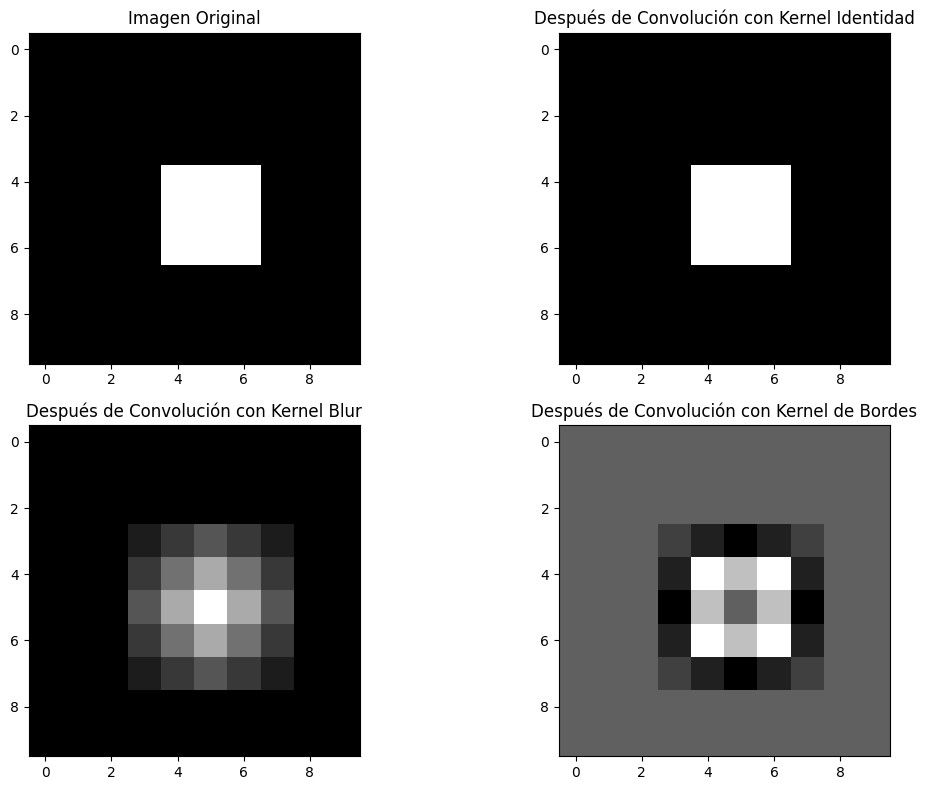

In [4]:
# Creamos una imagen simple (matriz 2D)
imagen = np.zeros((10, 10))
imagen[4:7, 4:7] = 1  # Un cuadrado en el centro

# Definimos diferentes kernels para diferentes efectos
kernel_identidad = np.array([[0, 0, 0], [0, 1, 0], [0, 0, 0]])
kernel_blur = np.ones((3, 3)) / 9  # Filtro de promedio para desenfoque
kernel_bordes = np.array([[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]])  # Detección de bordes

# Realizamos la convolución 2D con scipy
from scipy import signal as sg

conv_identidad = sg.convolve2d(imagen, kernel_identidad, mode='same', boundary='wrap')
conv_blur = sg.convolve2d(imagen, kernel_blur, mode='same', boundary='wrap')
conv_bordes = sg.convolve2d(imagen, kernel_bordes, mode='same', boundary='wrap')

# Visualización
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(imagen, cmap='gray')
plt.title("Imagen Original")

plt.subplot(2, 2, 2)
plt.imshow(conv_identidad, cmap='gray')
plt.title("Después de Convolución con Kernel Identidad")

plt.subplot(2, 2, 3)
plt.imshow(conv_blur, cmap='gray')
plt.title("Después de Convolución con Kernel Blur")

plt.subplot(2, 2, 4)
plt.imshow(conv_bordes, cmap='gray')
plt.title("Después de Convolución con Kernel de Bordes")

plt.tight_layout()
plt.show()

## Aplicaciones de la Convolución

La convolución tiene muchas aplicaciones importantes:

1. **Procesamiento de señales**: Filtrado de señales, eliminación de ruido
2. **Procesamiento de imágenes**: Desenfoque, detección de bordes, mejora de nitidez
3. **Redes Neuronales Convolucionales**: Extracción automática de características para reconocimiento de patrones
4. **Sistemas lineales**: Respuesta de sistemas a diferentes entradas

## Propiedades de la Convolución

- **Conmutativa**: $f * g = g * f$
- **Asociativa**: $f * (g * h) = (f * g) * h$
- **Distributiva sobre la suma**: $f * (g + h) = f * g + f * h$
- **Transformada de Fourier**: La convolución en el dominio del tiempo/espacio es equivalente a la multiplicación en el dominio de la frecuencia

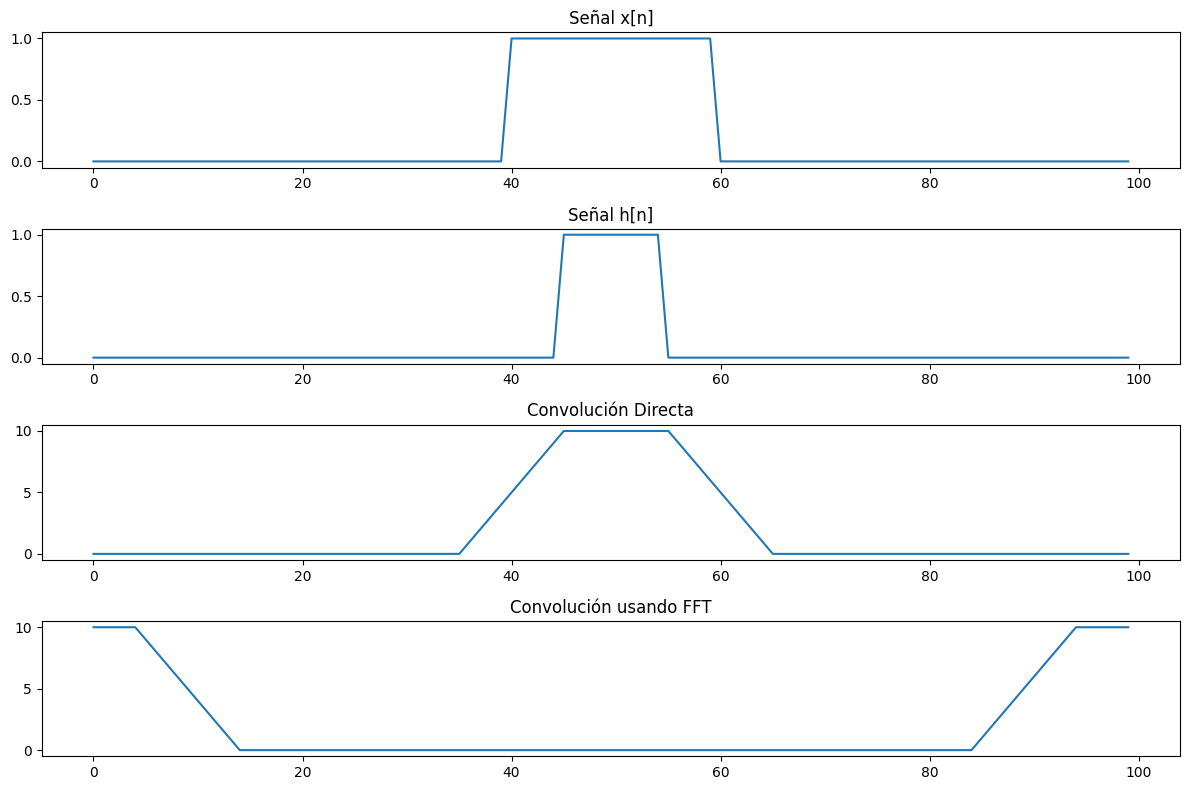

Diferencia máxima entre métodos: 10.000000000000002


In [5]:
# Ejemplo de convolución usando la transformada rápida de Fourier (FFT)
# La convolución en el dominio del tiempo = multiplicación en el dominio de frecuencia

# Señales más largas
x = np.zeros(100)
x[40:60] = 1  # Pulso rectangular

h = np.zeros(100)
h[45:55] = 1  # Otro pulso rectangular

# Método directo
y_direct = np.convolve(x, h, mode='same')

# Método con FFT
X = np.fft.fft(x)
H = np.fft.fft(h)
Y = X * H  # Multiplicación en el dominio de la frecuencia
y_fft = np.real(np.fft.ifft(Y))  # Regreso al dominio del tiempo

# Visualización
plt.figure(figsize=(12, 8))

plt.subplot(4, 1, 1)
plt.plot(x)
plt.title("Señal x[n]")

plt.subplot(4, 1, 2)
plt.plot(h)
plt.title("Señal h[n]")

plt.subplot(4, 1, 3)
plt.plot(y_direct)
plt.title("Convolución Directa")

plt.subplot(4, 1, 4)
plt.plot(y_fft)
plt.title("Convolución usando FFT")

plt.tight_layout()
plt.show()

print("Diferencia máxima entre métodos:", np.max(np.abs(y_direct - y_fft[:len(y_direct)])))